# Staging calls: load CSV, explore, sample downloads

This notebook loads `dataset/staging_calls.csv` (~10k+ rows, no header) with **Polars** (`scan_csv` → `collect`). It summarizes key fields, plots the **call duration** distribution, then downloads a **small subset** of recording URLs into `data/raw_audio/` for testing (adjust `TEST_DOWNLOAD_LIMIT`).

**Step:** Import libraries, set repo paths, and tune how many recordings to download (`TEST_DOWNLOAD_LIMIT`).

In [ ]:
from __future__ import annotations

from concurrent.futures import ThreadPoolExecutor, as_completed
from pathlib import Path
from urllib.parse import urlparse

import matplotlib.pyplot as plt
import polars as pl
import requests
from tqdm.auto import tqdm

# Paths (notebook cwd is usually repo root in JupyterLab)
REPO_ROOT = Path.cwd()
CSV_PATH = REPO_ROOT / "dataset" / "staging_calls.csv"
RAW_AUDIO_DIR = REPO_ROOT / "data" / "raw_audio"

# Distinct recording URLs to download (after filter). None = no cap (large).
TEST_DOWNLOAD_LIMIT = None
MAX_DOWNLOAD_WORKERS = 16  # parallel HTTP downloads (I/O-bound)

REQUEST_TIMEOUT = (10, 120)  # (connect, read) seconds
USER_AGENT = "call-contextual-extractor/1.0 (audio download test)"


**Step:** Lazy-scan the staging CSV, pick the call columns we need, then `collect()` into memory.

In [22]:
N_COLS = 47
RAW_NAMES = [f"c{i}" for i in range(N_COLS)]

# Lazy scan; project only the columns we need (scales better on huge CSVs)
lf = (
    pl.scan_csv(
        CSV_PATH,
        has_header=False,
        new_columns=RAW_NAMES,
        infer_schema_length=10_000,
    )
    .select(
        pl.col("c0").cast(pl.Int64, strict=False).alias("call_id"),
        pl.col("c1").alias("phone"),
        pl.col("c2").alias("carrier"),
        pl.col("c3").alias("recording_url"),
        pl.col("c4").cast(pl.Int64, strict=False).alias("duration_sec"),
        pl.col("c5").alias("start_at_raw"),
        pl.col("c6").alias("end_at_raw"),
        pl.col("c7").alias("call_status"),
        pl.col("c8").alias("hangup_cause"),
        pl.col("c9").alias("direction"),
    )
)

df = lf.collect()
df


call_id,phone,carrier,recording_url,duration_sec,start_at_raw,end_at_raw,call_status,hangup_cause,direction
i64,str,str,str,i64,str,str,str,str,str
770590,"""+84876818134""","""OTHER""","""https://storage004.ucall.vn/fi…",142,"""2026-04-05 02:20:09.000000 +00…","""2026-04-05 02:23:07.000000 +00…","""ANSWERED""","""NORMAL_CLEARING""","""OUTBOUND"""
770585,"""+84943118148""","""VINAPHONE""","""https://storage004.ucall.vn/fi…",13,"""2026-04-04 10:13:10.000000 +00…","""2026-04-04 10:13:45.000000 +00…","""ANSWERED""","""NORMAL_CLEARING""","""OUTBOUND"""
770584,"""+84943118148""","""VINAPHONE""","""https://storage004.ucall.vn/fi…",13,"""2026-04-04 10:13:10.000000 +00…","""2026-04-04 10:13:45.000000 +00…","""ANSWERED""","""NORMAL_CLEARING""","""OUTBOUND"""
770583,"""+84343438000""","""VIETTEL""","""https://storage004.ucall.vn/fi…",123,"""2026-04-04 09:53:08.000000 +00…","""2026-04-04 09:55:21.000000 +00…","""ANSWERED""","""NORMAL_CLEARING""","""OUTBOUND"""
770582,"""+84989524490""","""VIETTEL""","""https://storage004.ucall.vn/fi…",249,"""2026-04-04 09:28:51.000000 +00…","""2026-04-04 09:33:13.000000 +00…","""ANSWERED""","""NORMAL_CLEARING""","""OUTBOUND"""
…,…,…,…,…,…,…,…,…,…
7,"""+84827903789""","""VINAPHONE""","""https://storage004.ucall.vn/fi…",178,"""2025-06-02 08:17:08.000000 +00…","""2025-06-02 08:20:10.000000 +00…","""ANSWERED""","""NORMAL_CLEARING""","""OUTBOUND"""
6,"""+84975583171""","""VIETTEL""","""https://storage004.ucall.vn/fi…",677,"""2025-06-02 08:07:22.000000 +00…","""2025-06-02 08:18:35.000000 +00…","""ANSWERED""","""NORMAL_CLEARING""","""OUTBOUND"""
5,"""+84978954696""","""VIETTEL""","""https://storage004.ucall.vn/fi…",304,"""2025-06-02 08:11:06.000000 +00…","""2025-06-02 08:16:31.000000 +00…","""ANSWERED""","""NORMAL_CLEARING""","""OUTBOUND"""


**Step:** Quick sanity checks: size, missing URLs, duration nulls, and unique IDs/URLs.

In [23]:
print(f"Rows: {df.height:,}  Columns: {df.width}")
print(f"Approx. DataFrame size: {df.estimated_size() / (1024 * 1024):.2f} MiB")

bad_url = df.filter(
    pl.col("recording_url").is_null()
    | (pl.col("recording_url").fill_null("").str.strip_chars().str.len_chars() == 0)
).height
print(f"Rows without usable recording URL: {bad_url:,}")

pl.DataFrame(
    {
        "metric": [
            "null_duration_sec",
            "nonpositive_duration_sec",
            "unique_call_id",
            "unique_recording_url",
        ],
        "value": [
            df["duration_sec"].null_count(),
            df.filter(pl.col("duration_sec").is_not_null() & (pl.col("duration_sec") <= 0)).height,
            df["call_id"].n_unique(),
            df["recording_url"].n_unique(),
        ],
    }
)


Rows: 13,232  Columns: 10
Approx. DataFrame size: 3.14 MiB
Rows without usable recording URL: 0


metric,value
str,i64
"""null_duration_sec""",0
"""nonpositive_duration_sec""",0
"""unique_call_id""",13232
"""unique_recording_url""",12728


**Step:** Plot duration distribution; clip at the 99th percentile so the tail doesn’t squash the histogram.

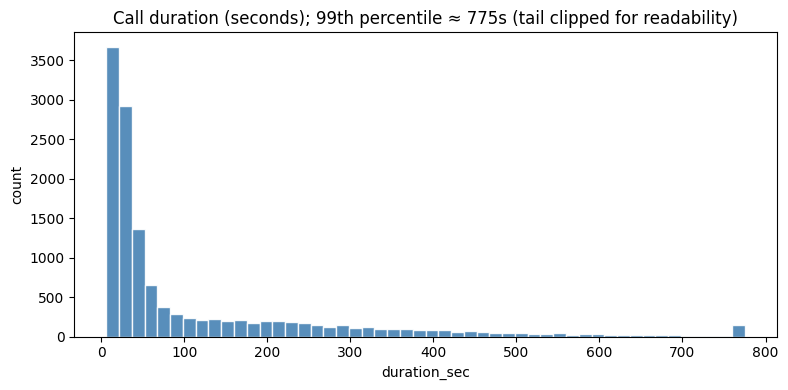

In [24]:
dur = df.filter(pl.col("duration_sec").is_not_null() & (pl.col("duration_sec") > 0))

if dur.height == 0:
    print("No rows with positive duration — skip plot.")
else:
    dur_cap = float(dur["duration_sec"].quantile(0.99))
    clipped = dur.with_columns(pl.col("duration_sec").clip(upper_bound=dur_cap))[
        "duration_sec"
    ].to_numpy()

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(clipped, bins=50, color="steelblue", edgecolor="white", alpha=0.9)
    ax.set_title(f"Call duration (seconds); 99th percentile ≈ {dur_cap:.0f}s (tail clipped for readability)")
    ax.set_xlabel("duration_sec")
    ax.set_ylabel("count")
    fig.tight_layout()
    plt.show()


**Step:** Build a small download queue (deduped URLs), download in parallel into `data/raw_audio/` (`MAX_DOWNLOAD_WORKERS`), show per-file status.

In [25]:
def local_name_for_url(url: str, call_id: int) -> str:
    path = urlparse(url).path
    base = path.rsplit("/", 1)[-1]
    return base if base else f"call_{call_id}.bin"


def download_one(url: str, dest: Path) -> tuple[bool, str]:
    if dest.exists() and dest.stat().st_size > 0:
        return True, "skipped (exists)"
    try:
        r = requests.get(
            url,
            timeout=REQUEST_TIMEOUT,
            headers={"User-Agent": USER_AGENT},
            stream=True,
        )
        r.raise_for_status()
        dest.parent.mkdir(parents=True, exist_ok=True)
        with dest.open("wb") as f:
            for chunk in r.iter_content(chunk_size=1 << 20):
                if chunk:
                    f.write(chunk)
        return True, "ok"
    except Exception as exc:
        return False, str(exc)


def download_row(row: dict) -> dict:
    name = local_name_for_url(row["recording_url"], row["call_id"])
    dest = RAW_AUDIO_DIR / name
    ok, msg = download_one(row["recording_url"], dest)
    return {"file": name, "ok": ok, "msg": msg}


queue = df.filter(
    pl.col("recording_url").fill_null("").str.strip_chars().str.len_chars() > 10
).unique(subset=["recording_url"], keep="first")
if TEST_DOWNLOAD_LIMIT is not None:
    queue = queue.head(TEST_DOWNLOAD_LIMIT)

print(f"Download queue: {queue.height} file(s) → {RAW_AUDIO_DIR}")
print(f"Workers: {MAX_DOWNLOAD_WORKERS}")

rows = list(queue.select(["call_id", "recording_url"]).iter_rows(named=True))
results: list[dict] = []
with ThreadPoolExecutor(max_workers=MAX_DOWNLOAD_WORKERS) as pool:
    futures = [pool.submit(download_row, row) for row in rows]
    for fut in tqdm(as_completed(futures), total=len(futures), desc="Downloading audio"):
        results.append(fut.result())

summary = pl.DataFrame(results)
print(
    summary.group_by("msg")
    .len()
    .sort("len", descending=True)
)
summary


Download queue: 12728 file(s) → /Users/megatunger/Github/call-contextual-extractor/data/raw_audio
Workers: 16


shape: (4, 2)
┌─────────────────────────────────┬──────┐
│ msg                             ┆ len  │
│ ---                             ┆ ---  │
│ str                             ┆ u32  │
╞═════════════════════════════════╪══════╡
│ ok                              ┆ 9843 │
│ skipped (exists)                ┆ 2883 │
│ 521 Server Error: <none> for u… ┆ 1    │
│ 521 Server Error: <none> for u… ┆ 1    │
└─────────────────────────────────┴──────┘


file,ok,msg
str,bool,str
"""c9e1569a-16ef-43c5-9c68-a0acca…",true,"""skipped (exists)"""
"""89dedd7f-043a-4e0b-b67d-d9e4a3…",true,"""skipped (exists)"""
"""b580b982-5dd6-43b8-b531-7fd312…",true,"""skipped (exists)"""
"""efd550db-a4db-4c60-881a-0f56f6…",true,"""skipped (exists)"""
"""b4e253fd-96a4-45d5-8af9-e3a24e…",true,"""skipped (exists)"""
…,…,…
"""d9ec2a08-faa0-445a-9723-24f17b…",true,"""ok"""
"""78567a50-5cd7-4a28-8564-4c816c…",true,"""ok"""
"""16a8611c-47f6-4202-b105-2803e3…",true,"""ok"""
